In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path("/Users/daniloruberti/Desktop/ADSP_31006_Final_Project2")

candidate_paths = [
    Path("merged_features_weekly.parquet"),
    Path("data/processed/merged_features_weekly.parquet"),
    Path.cwd() / "merged_features_weekly.parquet",
    Path.cwd() / "data/processed/merged_features_weekly.parquet",
    PROJECT_ROOT / "data/processed/merged_features_weekly.parquet",
]

file_path = next((path for path in candidate_paths if path.exists()), None)

if file_path is None:
    searched = "\n".join(str(path.resolve()) for path in candidate_paths)
    raise FileNotFoundError(
        f"Could not find 'merged_features_weekly.parquet'. Searched:\n{searched}"
    )

df = pd.read_parquet(file_path)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["commodity", "date"]).reset_index(drop=True)

In [7]:
sorted(df["commodity"].dropna().unique().tolist())

['Bulb Onions (Yellow)', 'Cabbage', 'Carrots', 'Lettuce']

In [8]:
commodity_name = "Cabbage"

plot_df = (
    df[df["commodity"] == commodity_name]
    .sort_values("date")
    .copy()
)

plot_df[[
    "date", "target_price", "target_lag_1",
    "target_roll_mean_4", "target_yoy_diff_52",
    "shock_2021q4_2023q1", "post_shock"
]].tail()

,date,target_price,target_lag_1,target_roll_mean_4,target_yoy_diff_52,shock_2021q4_2023q1,post_shock
1053,2026-01-23,0.616,0.634233,0.634233,0.0260,0,1
1054,2026-01-30,0.616,0.616000,0.629675,0.0260,0,1
1055,2026-02-06,0.585,0.616000,0.625117,-0.0225,0,1
1056,2026-02-13,0.585,0.585000,0.612808,-0.0225,0,1
1057,2026-02-20,0.620,0.585000,0.600500,0.0125,0,1


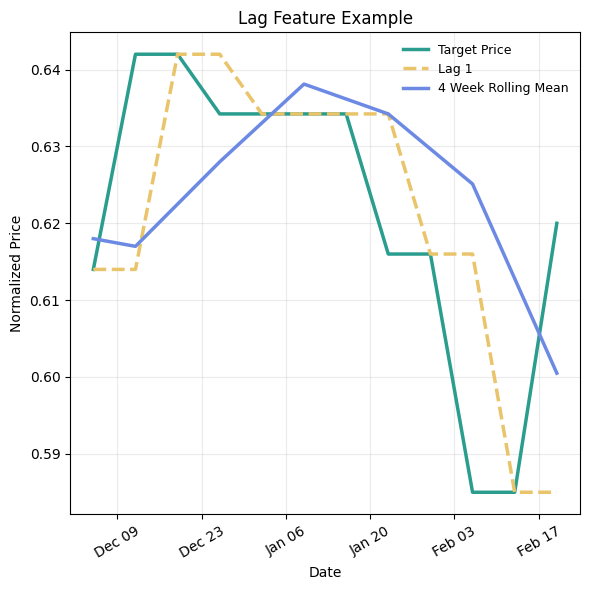

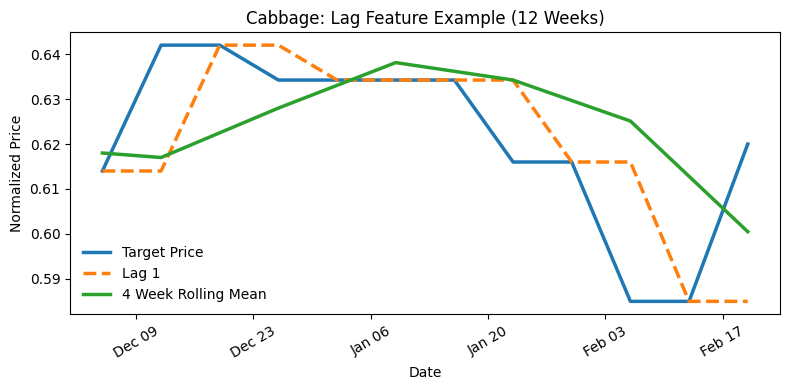

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

window = 12
zoom_df = plot_df.tail(window).copy()

fig, ax = plt.subplots(figsize=(6,6))   # <- vertical orientation

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(
    zoom_df["date"],
    zoom_df["target_price"],
    linewidth=2.5,
    label="Target Price",
    color="#2a9d8f"
)

ax.plot(
    zoom_df["date"],
    zoom_df["target_lag_1"],
    linewidth=2.5,
    linestyle="--",
    label="Lag 1",
    color="#e9c46a"
)

ax.plot(
    zoom_df["date"],
    zoom_df["target_roll_mean_4"],
    linewidth=2.5,
    label="4 Week Rolling Mean",
    color="#6c8ae4"
)

ax.set_title("Lag Feature Example", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")

ax.legend(frameon=False, fontsize=9)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

ax.tick_params(colors="black")

for spine in ax.spines.values():
    spine.set_color("black")

ax.grid(True, alpha=0.25)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# choose a small window
window = 12

zoom_df = plot_df.tail(window).copy()

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(zoom_df["date"], zoom_df["target_price"],
        linewidth=2.5, label="Target Price")

ax.plot(zoom_df["date"], zoom_df["target_lag_1"],
        linewidth=2.5, linestyle="--", label="Lag 1")

ax.plot(zoom_df["date"], zoom_df["target_roll_mean_4"],
        linewidth=2.5, label="4 Week Rolling Mean")

ax.set_title(f"{commodity_name}: Lag Feature Example (12 Weeks)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")

ax.legend(frameon=False)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

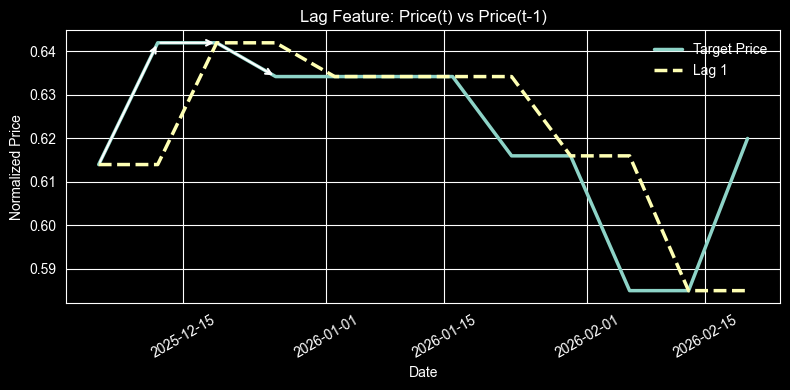

In [13]:
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(zoom_df["date"], zoom_df["target_price"], linewidth=2.5, label="Target Price")
ax.plot(zoom_df["date"], zoom_df["target_lag_1"], linewidth=2.5, linestyle="--", label="Lag 1")

# draw example lag arrows
for i in range(1,4):
    x1 = zoom_df["date"].iloc[i]
    y1 = zoom_df["target_price"].iloc[i]

    x0 = zoom_df["date"].iloc[i-1]
    y0 = zoom_df["target_lag_1"].iloc[i]

    ax.annotate(
        "",
        xy=(x1,y1),
        xytext=(x0,y0),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.set_title("Lag Feature: Price(t) vs Price(t-1)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price")
ax.legend(frameon=False)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

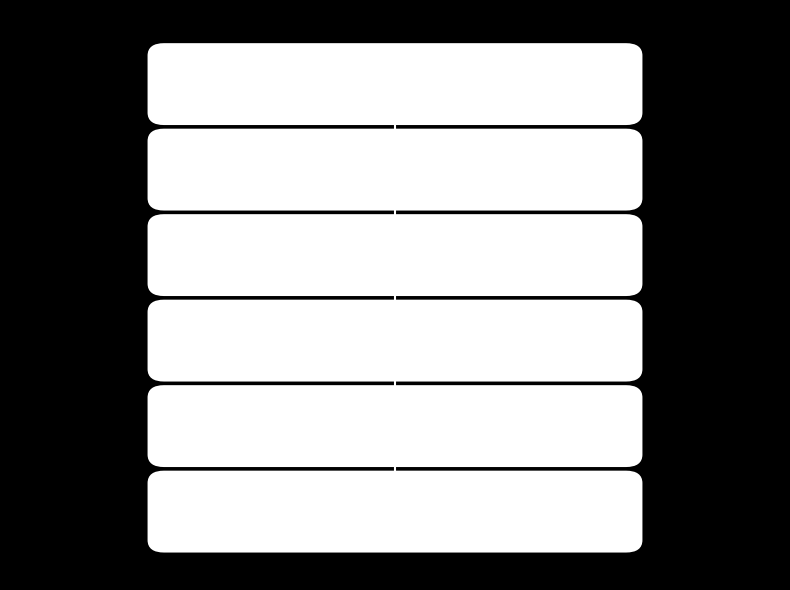

In [11]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

def add_box(x, y, w, h, text, fontsize=13):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.2",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)

add_box(2, 8.2, 6, 1.0, "Weekly Commodity Prices")
add_box(2, 6.7, 6, 1.0, "Temporal Features\nmonth, quarter, week_sin, week_cos")
add_box(2, 5.2, 6, 1.0, "Lag Features\ntarget_lag_1, 2, 4, 8, 12")
add_box(2, 3.7, 6, 1.0, "Rolling Statistics\nroll_mean_4, roll_std_4, roll_mean_8")
add_box(2, 2.2, 6, 1.0, "Shock + YoY Signals\nshock flags, yoy_diff_52, yoy_pct_52")
add_box(2, 0.7, 6, 1.0, "Forecast Ready Weekly Panel")

for y1, y2 in [(8.2, 7.7), (6.7, 6.2), (5.2, 4.7), (3.7, 3.2), (2.2, 1.7)]:
    ax.annotate("", xy=(5, y2), xytext=(5, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))

plt.tight_layout()
plt.show()